<a href="https://colab.research.google.com/github/nafilafiryal/data_mining/blob/main/5_Percobaan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install mlxtend

In [ ]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [ ]:
dataset = [
    ['roti', 'susu', 'telur'],
    ['roti', 'mentega', 'telur'],
    ['susu', 'mentega', 'roti', 'telur'],
    ['roti', 'susu'],
    ['roti', 'mentega', 'telur']
]

In [ ]:
te = TransactionEncoder()
te_data = te.fit(dataset).transform(dataset)
df = pd.DataFrame(te_data, columns=te.columns_)
df

,mentega,roti,susu,telur
0,False,True,True,True
1,True,True,False,True
2,True,True,True,True
3,False,True,True,False
4,True,True,False,True


In [ ]:
frequent_items = apriori(df, min_support=0.4, use_colnames=True)
frequent_items

,support,itemsets
0,0.6,(mentega)
1,1.0,(roti)
2,0.6,(susu)
3,0.8,(telur)
4,0.6,"(roti, mentega)"
5,0.6,"(mentega, telur)"
6,0.6,"(roti, susu)"
7,0.8,"(roti, telur)"
8,0.4,"(susu, telur)"
9,0.6,"(roti, mentega, telur)"


In [ ]:
rules = association_rules(frequent_items, metric="confidence", min_threshold=0.5)
rules

/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(roti),(mentega),1.0,0.6,0.6,0.600000,1.000000,1.0,0.00,1.0,0.000000,0.60,0.000000,0.800000
1,(mentega),(roti),0.6,1.0,0.6,1.000000,1.000000,1.0,0.00,inf,0.000000,0.60,0.000000,0.800000
2,(mentega),(telur),0.6,0.8,0.6,1.000000,1.250000,1.0,0.12,inf,0.500000,0.75,1.000000,0.875000
3,(telur),(mentega),0.8,0.6,0.6,0.750000,1.250000,1.0,0.12,1.6,1.000000,0.75,0.375000,0.875000
4,(roti),(susu),1.0,0.6,0.6,0.600000,1.000000,1.0,0.00,1.0,0.000000,0.60,0.000000,0.800000
5,(susu),(roti),0.6,1.0,0.6,1.000000,1.000000,1.0,0.00,inf,0.000000,0.60,0.000000,0.800000
6,(roti),(telur),1.0,0.8,0.8,0.800000,1.000000,1.0,0.00,1.0,0.000000,0.80,0.000000,0.900000
7,(telur),(roti),0.8,1.0,0.8,1.000000,1.000000,1.0,0.00,inf,0.000000,0.80,0.000000,0.900000
8,(susu),(telur),0.6,0.8,0.4,0.666667,0.833333,1.0,-0.08,0.6,-0.333333,0.40,-0.666667,0.583333
9,(telur),(susu),0.8,0.6,0.4,0.500000,0.833333,1.0,-0.08,0.8,-0.500000,0.40,-0.250000,0.583333


In [ ]:
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

,antecedents,consequents,support,confidence,lift
0,(roti),(mentega),0.6,0.600000,1.000000
1,(mentega),(roti),0.6,1.000000,1.000000
2,(mentega),(telur),0.6,1.000000,1.250000
3,(telur),(mentega),0.6,0.750000,1.250000
4,(roti),(susu),0.6,0.600000,1.000000
5,(susu),(roti),0.6,1.000000,1.000000
6,(roti),(telur),0.8,0.800000,1.000000
7,(telur),(roti),0.8,1.000000,1.000000
8,(susu),(telur),0.4,0.666667,0.833333
9,(telur),(susu),0.4,0.500000,0.833333


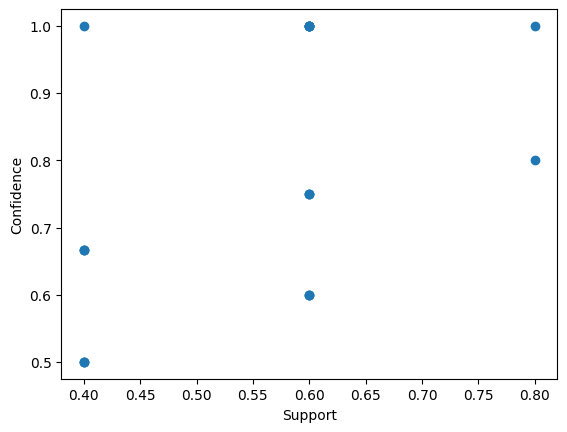

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(rules['support'], rules['confidence'])
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.show()